# Recommended setup and example dataset

In [1]:
import remeta
import numpy as np
%load_ext autoreload
%autoreload 2

Generally, ReMeta’s default configuration reflects our recommended setup. However, we strongly suggest considering a few additional tweaks.

## Tweak 1: random effects modeling of metacognitive noise

Metacognitive noise is both a key parameter of ReMeta and among the most difficult to estimate reliably. This is particularly true for observers with moderate to high type 1 noise, because it is difficult to disentangle whether variability in confidence ratings reflects type 1 uncertainty or metacognitive noise.

To improve the robustness of metacognitive-noise inference, we recommend estimating metacognitive noise in a random-effects setup, where individual estimates are regularized by the overall group-level tendency.

In [2]:
cfg = remeta.Configuration()
cfg.param_type2_noise.group = 'random'

Note that this requires ReMeta to be fitted in "group mode", i.e. passing all subject data at once to `remetaObject.fit()` (see [Group parameters](group_estimation_priors.ipynb)).

## Tweak 2: linearize stimulus input

Because stimulus magnitude if often not available in interval scale, consider linearizing your stimulus input. See [Stimulus evidence](stimulus_evidence.ipynb) for details. To this aim either set

In [3]:
cfg.optim_type1_linearize = True

or pass it to `remetaObject.fit([...], linearize=True)`.

## Tweak 3: grid search for type 2 parameters

Type 2 parameter estimation with gradien-based methods sometims does not find the global minimum, especially if there are are multple confidence criteria. We therefore recommended to use an initial gridsearch covering a sensible range of the parameter space:

In [4]:
cfg.optim_type2_gridsearch = True

## Example dataset

To illustrate the recommended usage of ReMeta, we use a dataset of 20 participants by Shekhar and Rahnev [@Shekhar2021].

In [5]:
import pandas as pd
# The dataset can be found here:
# https://github.com/coconeuro/remeta/blob/main/remeta/demo_data/shekhar_2021_session1.csv
df = pd.read_csv('../data/shekhar_2021_session1.csv')

In [6]:
df.head()

,subject,stimulus_id,stimuli,choices,confidence
0,0,1,0.666667,1,0.142
1,0,1,0.333333,1,0.388
2,0,1,0.666667,1,0.124
3,0,0,-0.666667,1,0.404
4,0,0,-0.333333,1,0.242


The dataset has 20 participants and 800 trials per participant (overall there were 2800 trials, but this is only session 1 data):

In [7]:
df.groupby('subject').size().values

array([800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800,
       800, 800, 800, 800, 800, 800, 800])

There were three stimulus magnitude levels (difficulties) and confidence was a continuous variable between 0 and 1.

The goal is to fit ReMeta to all participants at once. We therefore create lists of (subject-level) lists for the variables `stimuli`, `choices` and `confidence`:

In [8]:
stimuli, choices, confidence = [df.groupby('subject')[col].apply(list).values for col in ('stimuli', 'choices', 'confidence')]

We use the recommended tweaks above and fit the model. Moreover, as mentioned in the section [# Type 2: the metacognitive stage](type2.ipynb), we recommend to fit confidence criteria even for continuous data. Below, we therefore pass `n_ratings=4` to the `fit` method (implying 3 confidence criteria).

In [9]:
import remeta
cfg = remeta.Configuration()
cfg.param_type2_noise.group = 'random'
cfg.optim_type1_linearize = True
cfg.optim_type2_gridsearch = True
cfg.optim_num_cores = -1  # multiprocessing: -1 = use all cores except one
rem = remeta.ReMeta(cfg)
rem.fit(stimuli, choices, confidence, verbosity=0)  # Takes at least a few minutes
result = rem.summary()

Fitting of confidence criteria is enabled, but `n_ratings` was not passed. Using the default of 4 confidence ratings / 3 confidence criteria. To suppress this message, pass `n_ratings=X` to the `fit` method.


As noted by the message, by default ReMeta fits four confidence ratings (corresponding to 3 confidence criteria) − even if confidence ratings are continuous as in this case.

In [10]:
# import joblib
# joblib.dump(rem, '../data/shekhar_2021_session1.joblib')

In [11]:
# import joblib
# rem = joblib.load('../data/shekhar_2021_session1.joblib')

We can visualize the distribution of the parameters

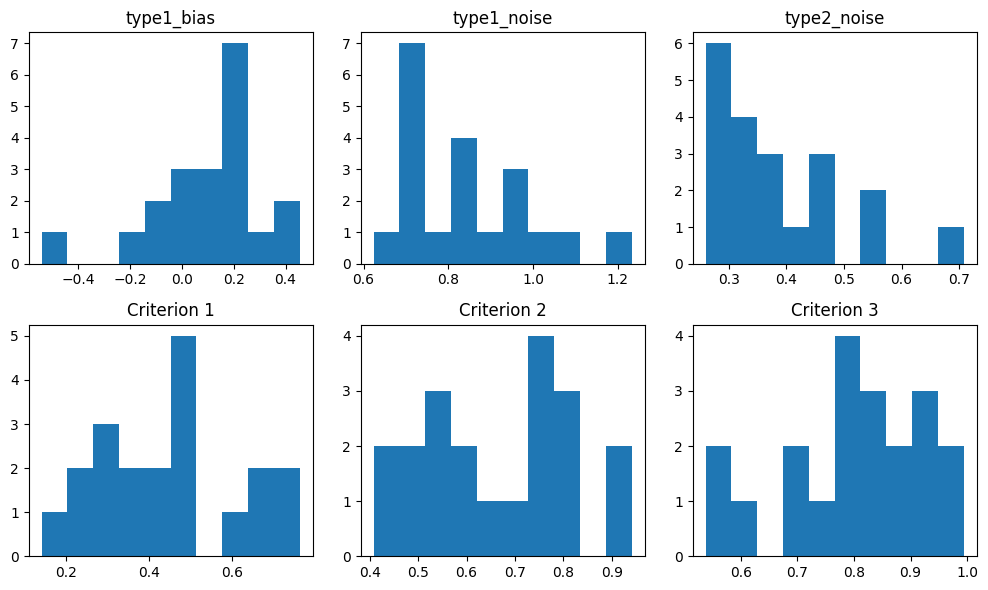

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for i, param in enumerate(['type1_bias', 'type1_noise', 'type2_noise']):
    plt.subplot(2, 3, i + 1)
    plt.hist([p[param] for p in result.params])
    plt.title(param)
for i in range(3):
    plt.subplot(2, 3, i + 4)
    plt.hist([p['type2_criteria'][i] for p in result.params])
    plt.title(f'Criterion {i + 1}')
plt.tight_layout()

... and the confidence bias:

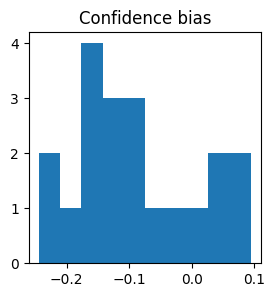

In [13]:
plt.figure(figsize=(3, 3))
plt.hist([p['type2_criteria_confidence_bias'] for p in result.params_extra])
plt.title('Confidence bias');

It is strongly recommended to validate the fitted parameters against some descriptive measures.

First, type 1 noise should correlate (negatively) with accuracy:

Text(0.97, 0.9, 'r=-0.933 (p=0.000)')

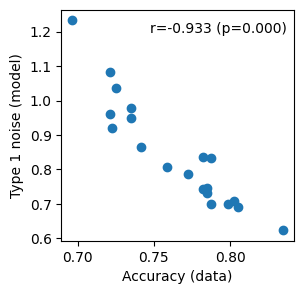

In [14]:
data_accuracy = [np.mean((np.array(stim) > 0) == np.array(dec, bool)) for stim, dec in zip(stimuli, choices)]
model_type1_noise = [p['type1_noise'] for p in result.params]
plt.figure(figsize=(3, 3))
plt.scatter(data_accuracy, model_type1_noise)
plt.xlabel('Accuracy (data)')
plt.ylabel('Type 1 noise (model)')
from scipy.stats import spearmanr
r, p = spearmanr(data_accuracy, model_type1_noise)
plt.text(0.97, 0.9, f'r={r:.3f} (p={p:.3f})', transform=plt.gca().transAxes, ha='right')

Second, type 2 noise should bear some relationship with how much average confidence differs between correct and incorrect choices (higher metacognitive noise -> less pronounced difference):

Text(0.97, 0.9, 'r=-0.541 (p=0.014)')

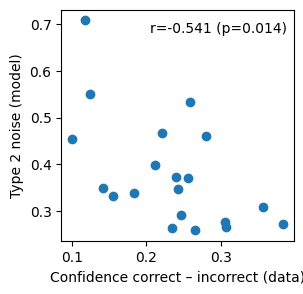

In [15]:
data_confidence_correct = [np.mean([c for i, c in enumerate(conf) if int(stim[i] > 0) == dec[i]]) for stim, dec, conf in zip(stimuli, choices, confidence)]
data_confidence_incorrect = [np.mean([c for i, c in enumerate(conf) if int(stim[i] > 0) != dec[i]]) for stim, dec, conf in zip(stimuli, choices, confidence)]
data_confidence_correct_m_incorrect = np.array(data_confidence_correct) - np.array(data_confidence_incorrect)
model_type2_noise = [p['type2_noise'] for p in result.params]
plt.figure(figsize=(3, 3))
plt.scatter(data_confidence_correct_m_incorrect, model_type2_noise)
plt.xlabel('Confidence correct – incorrect (data)')
plt.ylabel('Type 2 noise (model)')
r, p = spearmanr(data_confidence_correct_m_incorrect, model_type2_noise)
plt.text(0.97, 0.9, f'r={r:.3f} (p={p:.3f})', transform=plt.gca().transAxes, ha='right')

Third, the confidence bias should typically correlate positively with average confidence:

Text(0.03, 0.9, 'r=0.938 (p=0.000)')

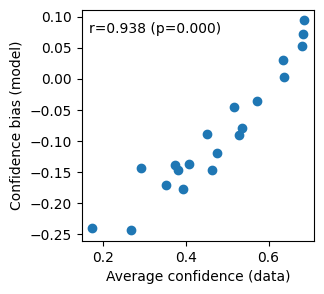

In [16]:
data_average_confidence = [np.mean(conf) for conf in confidence]
model_confidence_bias = [p['type2_criteria_confidence_bias'] for p in result.params_extra]
plt.figure(figsize=(3, 3))
plt.scatter(data_average_confidence, model_confidence_bias)
plt.xlabel('Average confidence (data)')
plt.ylabel('Confidence bias (model)')
r, p = spearmanr(data_average_confidence, model_confidence_bias)
plt.text(0.03, 0.9, f'r={r:.3f} (p={p:.3f})', transform=plt.gca().transAxes)